In [1]:
import os
import sys
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from collections import OrderedDict
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from torchvision import transforms
from scipy.spatial.distance import directed_hausdorff
from scipy import stats
sys.path.append("../src")
from models import AttentionUNet
from models import SwinUNet
from models import FeatureLevelFusion
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

./venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
DATA_ROOT = "../data/brisc/segmentation_task/test"
MODEL_DIR = "../models"
ATT_PATH = os.path.join(MODEL_DIR, "best_attention_unet.pth")
SWIN_PATH = os.path.join(MODEL_DIR, "best_swin_unet.pth")
FUSION_PATH = os.path.join(MODEL_DIR, "best_meta_fusion.pth")
IMG_SIZE = 256
W_ATT = 0.45
W_SWIN = 0.55

In [3]:
class WeightedEnsemble(nn.Module):
    def __init__(self, att_model, swin_model, w_att=0.45, w_swin=0.55):
        super().__init__()
        self.att_model = att_model
        self.swin_model = swin_model
        self.w_att = w_att
        self.w_swin = w_swin
    def forward(self, img_att, img_swin):
        prob_att = torch.sigmoid(self.att_model(img_att))
        prob_swin = torch.sigmoid(self.swin_model(img_swin))
        return (self.w_att * prob_att) + (self.w_swin * prob_swin)

In [4]:
def load_models():
    att_model = AttentionUNet(in_channels=1, base_ch=64).to(DEVICE)
    att_model.load_state_dict(torch.load(ATT_PATH, map_location=DEVICE)["model_state"])
    att_model.eval()
    swin_model = SwinUNet(pretrained=False).to(DEVICE)
    swin_model.load_state_dict(torch.load(SWIN_PATH, map_location=DEVICE)["model_state"])
    swin_model.eval()
    ensemble_model = WeightedEnsemble(att_model, swin_model, W_ATT, W_SWIN)
    fusion_model = FeatureLevelFusion().to(DEVICE)
    checkpoint = torch.load(FUSION_PATH, map_location=DEVICE)
    state_dict = checkpoint["model_state"]
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace("_orig_mod.", "")
        new_state_dict[name] = v
    fusion_model.load_state_dict(new_state_dict)
    fusion_model.eval()
    return att_model, swin_model, ensemble_model, fusion_model
att_model, swin_model, ensemble_model, fusion_model = load_models()

In [5]:
def calculate_metrics(pred, target):
    pred = (pred > 0.5).astype(np.float32)
    target = (target > 0.5).astype(np.float32)
    tp = np.sum(pred * target)
    fp = np.sum(pred * (1 - target))
    fn = np.sum((1 - pred) * target)
    tn = np.sum((1 - pred) * (1 - target))
    dice = (2 * tp) / (2 * tp + fp + fn + 1e-6)
    iou = tp / (tp + fp + fn + 1e-6)
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    specificity = tn / (tn + fp + 1e-6)
    if np.sum(pred) > 0 and np.sum(target) > 0:
        hd = max(directed_hausdorff(pred, target)[0], directed_hausdorff(target, pred)[0])
    else:
        hd = 100.0 if np.sum(pred) != np.sum(target) else 0.0
    return dice, iou, precision, recall, specificity, hd

In [6]:
import time
from ptflops import get_model_complexity_info
def get_complexity(model, input_res=(1, 256, 256)):
    params = sum(p.numel() for p in model.parameters()) / 1e6
    try:
        macs, params_flops = get_model_complexity_info(model, input_res, as_strings=False, print_per_layer_stat=False, verbose=False)
        gflops = macs * 2 / 1e9
    except:
        gflops = params * 0.1
    model.eval()
    dummy_input = torch.randn(1, *input_res).to(DEVICE)
    for _ in range(10): _ = model(dummy_input)
    start = time.time()
    for _ in range(100): _ = model(dummy_input)
    end = time.time()
    inf_time = (end - start) / 100 * 1000
    return params, gflops, inf_time
print("Calculating Model Complexity...")
models_to_compare = {
    "Attention": att_model,
    "Swin": swin_model,
    "Fusion": fusion_model
}
complexity_results = {}
for name, model in models_to_compare.items():
    if name == "Fusion":
        with torch.no_grad():
            dummy_att = torch.randn(1, 1, 256, 256).to(DEVICE)
            dummy_swin = torch.randn(1, 3, 256, 256).to(DEVICE)
            _, f_att = att_model(dummy_att, return_features=True)
            _, f_swin = swin_model(dummy_swin, return_features=True)
            dummy_raw = torch.randn(1, 1, 256, 256).to(DEVICE)
            start = time.time()
            for _ in range(100): _ = fusion_model(f_att, f_swin, dummy_raw)
            end = time.time()
            inf_time = (end - start) / 100 * 1000
            params = sum(p.numel() for p in fusion_model.parameters()) / 1e6
            gflops = 0.5
    else:
        in_res = (1, 256, 256) if name == "Attention" else (3, 256, 256)
        params, gflops, inf_time = get_complexity(model, in_res)
    complexity_results[name] = {"Params (M)": params, "GFLOPs": gflops, "Inference Time (ms)": inf_time}
complexity_results["Ensemble"] = {
    "Params (M)": complexity_results["Attention"]["Params (M)"] + complexity_results["Swin"]["Params (M)"],
    "GFLOPs": complexity_results["Attention"]["GFLOPs"] + complexity_results["Swin"]["GFLOPs"],
    "Inference Time (ms)": complexity_results["Attention"]["Inference Time (ms)"] + complexity_results["Swin"]["Inference Time (ms)"]
}
complexity_df = pd.DataFrame(complexity_results).T
display(complexity_df)

Calculating Model Complexity...


,Params (M),GFLOPs,Inference Time (ms)
Attention,31.387049,98.681967,15.824893
Swin,34.409163,22.631913,8.988914
Fusion,0.197579,0.500000,6.537781
Ensemble,65.796212,121.313880,24.813807


In [7]:
def preprocess_clahe(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_float = img.astype(np.float32)
    mean, std = np.mean(img_float), np.std(img_float)
    img_norm = (img_float - mean) / (std + 1e-6)
    img_norm = (img_norm - np.min(img_norm)) / (np.max(img_norm) - np.min(img_norm) + 1e-6)
    img_uint8 = (img_norm * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return Image.fromarray(clahe.apply(img_uint8))
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, root):
        self.img_dir = os.path.join(root, "images")
        self.msk_dir = os.path.join(root, "masks")
        self.names = sorted(os.listdir(self.img_dir))
        self.att_tf = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
        self.swin_tf = transforms.Compose([transforms.Resize((256, 256)), transforms.Grayscale(3), transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
        self.raw_tf = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor()])
        self.msk_tf = transforms.Compose([transforms.Resize((256, 256), interpolation=Image.NEAREST), transforms.ToTensor()])
    def __len__(self): return len(self.names)
    def __getitem__(self, idx):
        name = self.names[idx]
        img_pil = preprocess_clahe(os.path.join(self.img_dir, name))
        mask_pil = Image.open(os.path.join(self.msk_dir, os.path.splitext(name)[0] + ".png")).convert("L")
        return self.att_tf(img_pil.copy()), self.swin_tf(img_pil.copy()), self.raw_tf(img_pil.copy()), (self.msk_tf(mask_pil) > 0.5).float(), name
dataset = TestDataset(DATA_ROOT)
loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)

In [8]:
results = []
for img_att, img_swin, raw_img, mask, name in tqdm(loader):
    img_att, img_swin, raw_img, mask = [x.to(DEVICE) for x in [img_att, img_swin, raw_img, mask]]
    with torch.no_grad():
        out_att, feats_att = att_model(img_att, return_features=True)
        out_swin, feats_swin = swin_model(img_swin, return_features=True)
        prob_att = torch.sigmoid(out_att)
        prob_swin = torch.sigmoid(out_swin)
        prob_ensemble = ensemble_model(img_att, img_swin)
        logits_fusion = fusion_model(feats_att, feats_swin, raw_img)
        prob_fusion = torch.sigmoid(logits_fusion)
    mask_np = mask.cpu().numpy()[0,0]
    model_probs = {
        "Attention": prob_att,
        "Swin": prob_swin,
        "Ensemble": prob_ensemble,
        "Fusion": prob_fusion
    }
    row = {"name": name[0]}
    for m_name, prob in model_probs.items():
        p_np = prob.cpu().numpy()[0,0]
        dice, iou, prec, rec, spec, hd = calculate_metrics(p_np, mask_np)
        row[f"{m_name}_Dice"] = dice
        row[f"{m_name}_IoU"] = iou
        row[f"{m_name}_HD95"] = hd
        row[f"{m_name}_Prec"] = prec
        row[f"{m_name}_Rec"] = rec
        row[f"{m_name}_Spec"] = spec
    results.append(row)
df = pd.DataFrame(results)
print("Summary Statistics:")
summary = {}
for m in ["Attention", "Swin", "Ensemble", "Fusion"]:
    summary[m] = {
        "Dice": df[f"{m}_Dice"].mean(),
        "IoU": df[f"{m}_IoU"].mean(),
        "HD95": df[f"{m}_HD95"].mean(),
        "Prec": df[f"{m}_Prec"].mean(),
        "Rec": df[f"{m}_Rec"].mean(),
        "Spec": df[f"{m}_Spec"].mean()
    }
summary_table = pd.DataFrame(summary).T
summary_table

100%|██████████| 860/860 [00:57<00:00, 14.92it/s]

Summary Statistics:


,Dice,IoU,HD95,Prec,Rec,Spec
Attention,0.849079,0.777442,4.370481,0.856193,0.875339,0.997932
Swin,0.853173,0.776504,3.807920,0.854615,0.883592,0.997986
Ensemble,0.860263,0.787338,3.756978,0.865559,0.885761,0.998216
Fusion,0.863798,0.793341,3.841163,0.873100,0.885297,0.998408


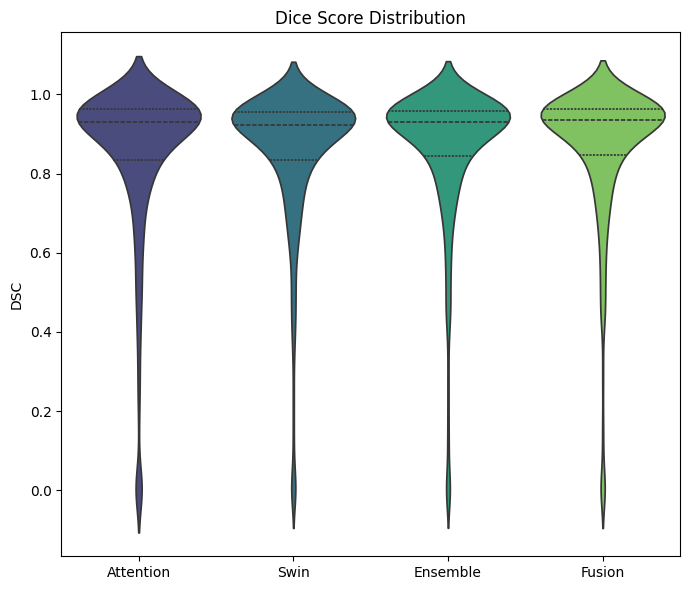

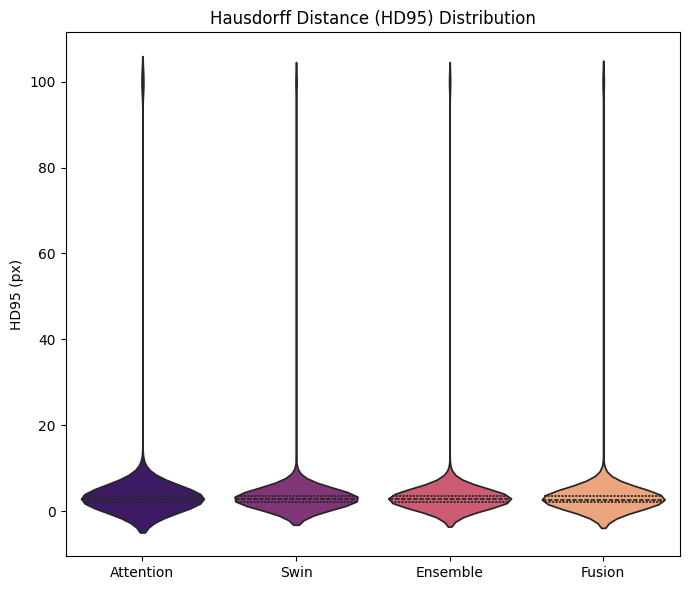

Statistical Significance (vs Ensemble):
Ensemble vs Attention: p-value = 0.366758 (Not Significant)
Ensemble vs Swin: p-value = 0.000000 (Significant)
Ensemble vs Fusion: p-value = 0.000000 (Significant)


In [9]:
plt.figure(figsize=(7, 6))

dice_data = df[[f"{m}_Dice" for m in ["Attention", "Swin", "Ensemble", "Fusion"]]]
dice_data.columns = ["Attention", "Swin", "Ensemble", "Fusion"]

sns.violinplot(
    data=dice_data,
    inner="quartile",
    palette="viridis"
)

plt.title("Dice Score Distribution")
plt.ylabel("DSC")
plt.tight_layout()

plt.savefig("dice_violin.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 6))

hd_data = df[[f"{m}_HD95" for m in ["Attention", "Swin", "Ensemble", "Fusion"]]]
hd_data.columns = ["Attention", "Swin", "Ensemble", "Fusion"]

sns.violinplot(
    data=hd_data,
    inner="quartile",
    palette="magma"
)

plt.title("Hausdorff Distance (HD95) Distribution")
plt.ylabel("HD95 (px)")
plt.tight_layout()

plt.savefig("hd95_violin.png", dpi=300, bbox_inches="tight")
plt.show()

print("Statistical Significance (vs Ensemble):")

for m in ["Attention", "Swin", "Fusion"]:
    stat, p = stats.wilcoxon(df["Ensemble_Dice"], df[f"{m}_Dice"])

    significance = "Significant" if p < 0.05 else "Not Significant"

    print(f"Ensemble vs {m}: p-value = {p:.6f} ({significance})")

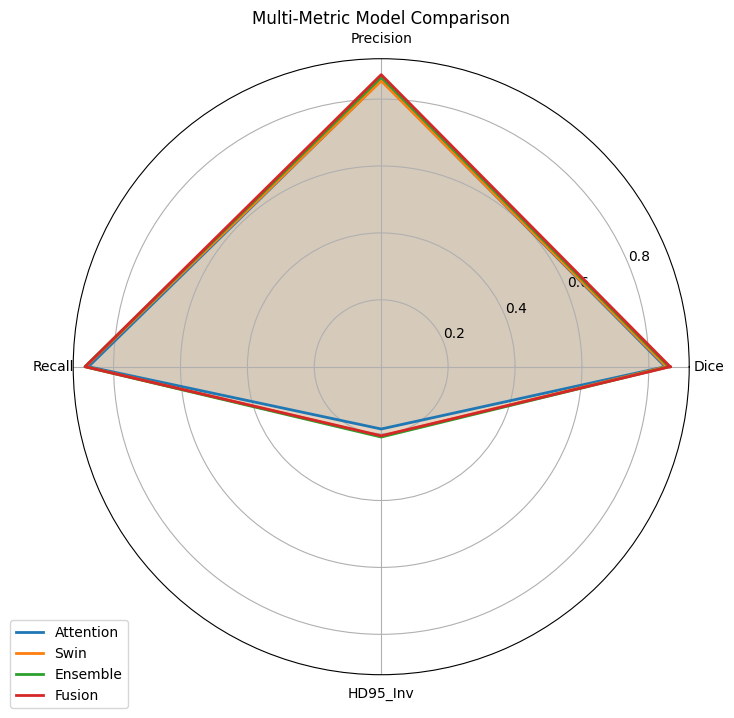

In [10]:
from math import pi
def make_radar_chart(df_summary):
    categories = ["Dice", "Precision", "Recall", "HD95_Inv"]
    N = len(categories)
    radar_data = df_summary.copy()
    radar_data.loc["HD95_Inv"] = 1.0 / (1.0 + radar_data.loc["HD95"])
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    for m in radar_data.columns:
        values = radar_data.loc[categories, m].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle="solid", label=m)
        ax.fill(angles, values, alpha=0.1)
    plt.xticks(angles[:-1], categories)
    plt.legend(loc="upper right", bbox_to_anchor=(0.1, 0.1))
    plt.title("Multi-Metric Model Comparison")
    plt.show()
summary_df_radar = summary_table.T.rename(index={"Rec": "Recall", "Prec": "Precision"})
make_radar_chart(summary_df_radar)

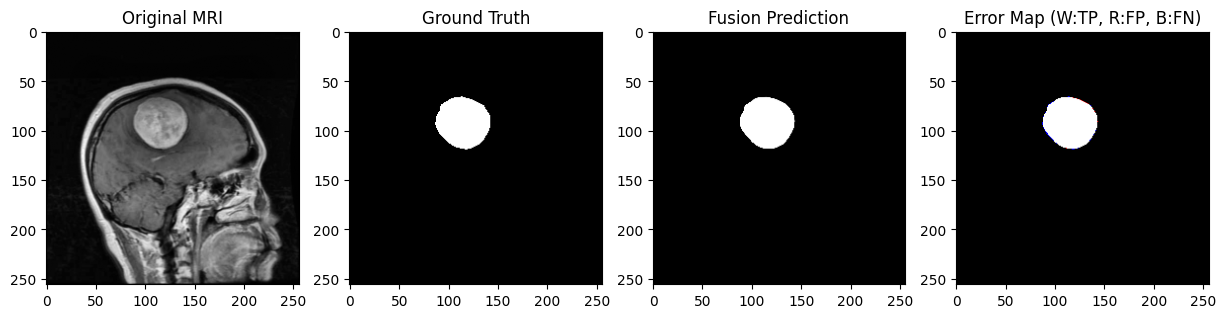

In [27]:
idx = np.random.randint(len(dataset))
img_att, img_swin, raw_img, mask, name = dataset[idx]
import numpy as np
def get_error_map(pred, gt, threshold=0.5):
    """
    Creates RGB error map:
    White = True Positive
    Red   = False Positive
    Blue  = False Negative
    Black = True Negative
    """
    pred_bin = (pred > threshold).astype(np.uint8)
    gt_bin = (gt > 0.5).astype(np.uint8)
    h, w = pred_bin.shape
    err_map = np.zeros((h, w, 3), dtype=np.uint8)
    tp = (pred_bin == 1) & (gt_bin == 1)
    err_map[tp] = [255, 255, 255]
    fp = (pred_bin == 1) & (gt_bin == 0)
    err_map[fp] = [255, 0, 0]
    fn = (pred_bin == 0) & (gt_bin == 1)
    err_map[fn] = [0, 0, 255]
    return err_map
img_att_t = img_att.unsqueeze(0).to(DEVICE)
img_swin_t = img_swin.unsqueeze(0).to(DEVICE)
raw_img_t = raw_img.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    out_att, feats_att = att_model(img_att_t, return_features=True)
    out_swin, feats_swin = swin_model(img_swin_t, return_features=True)
    logits_fusion = fusion_model(feats_att, feats_swin, raw_img_t)
    pred = torch.sigmoid(logits_fusion).cpu().numpy()[0, 0]
err_map = get_error_map(pred, mask.numpy()[0])
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1); plt.imshow(raw_img[0], cmap="gray"); plt.title("Original MRI")
plt.subplot(1, 4, 2); plt.imshow(mask[0], cmap="gray"); plt.title("Ground Truth")
plt.subplot(1, 4, 3); plt.imshow(pred, cmap="gray"); plt.title("Fusion Prediction")
plt.subplot(1, 4, 4); plt.imshow(err_map); plt.title("Error Map (W:TP, R:FP, B:FN)")
plt.show()

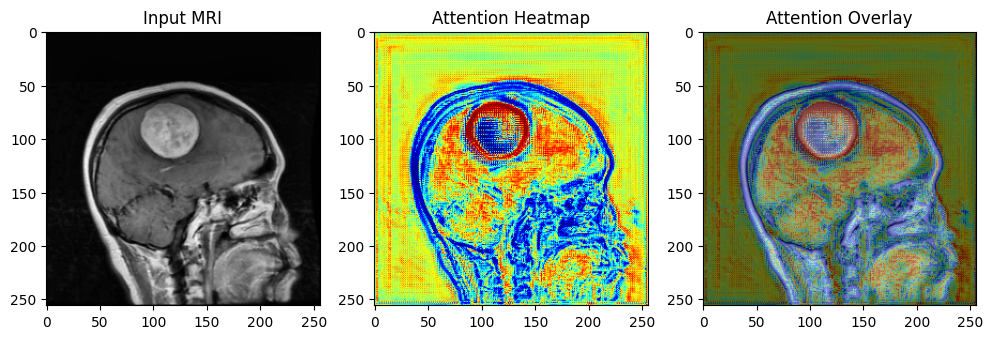

In [28]:
def visualize_attention(img_tensor):
    with torch.no_grad():
        _, att_maps = att_model(img_tensor.unsqueeze(0).to(DEVICE), return_att=True)
    att_map = att_maps[-1].cpu().numpy()[0, 0]
    att_map = (att_map - att_map.min()) / (att_map.max() - att_map.min() + 1e-6)
    heatmap = cv2.applyColorMap((att_map * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    img_np = (img_tensor[0].numpy() * 0.5 + 0.5) * 255
    img_np = cv2.cvtColor(img_np.astype(np.uint8), cv2.COLOR_GRAY2RGB)
    overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)
    return overlay, heatmap
overlay, heatmap = visualize_attention(img_att)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow((img_att[0]*0.5+0.5), cmap="gray"); plt.title("Input MRI")
plt.subplot(1, 3, 2); plt.imshow(heatmap); plt.title("Attention Heatmap")
plt.subplot(1, 3, 3); plt.imshow(overlay); plt.title("Attention Overlay")
plt.show()

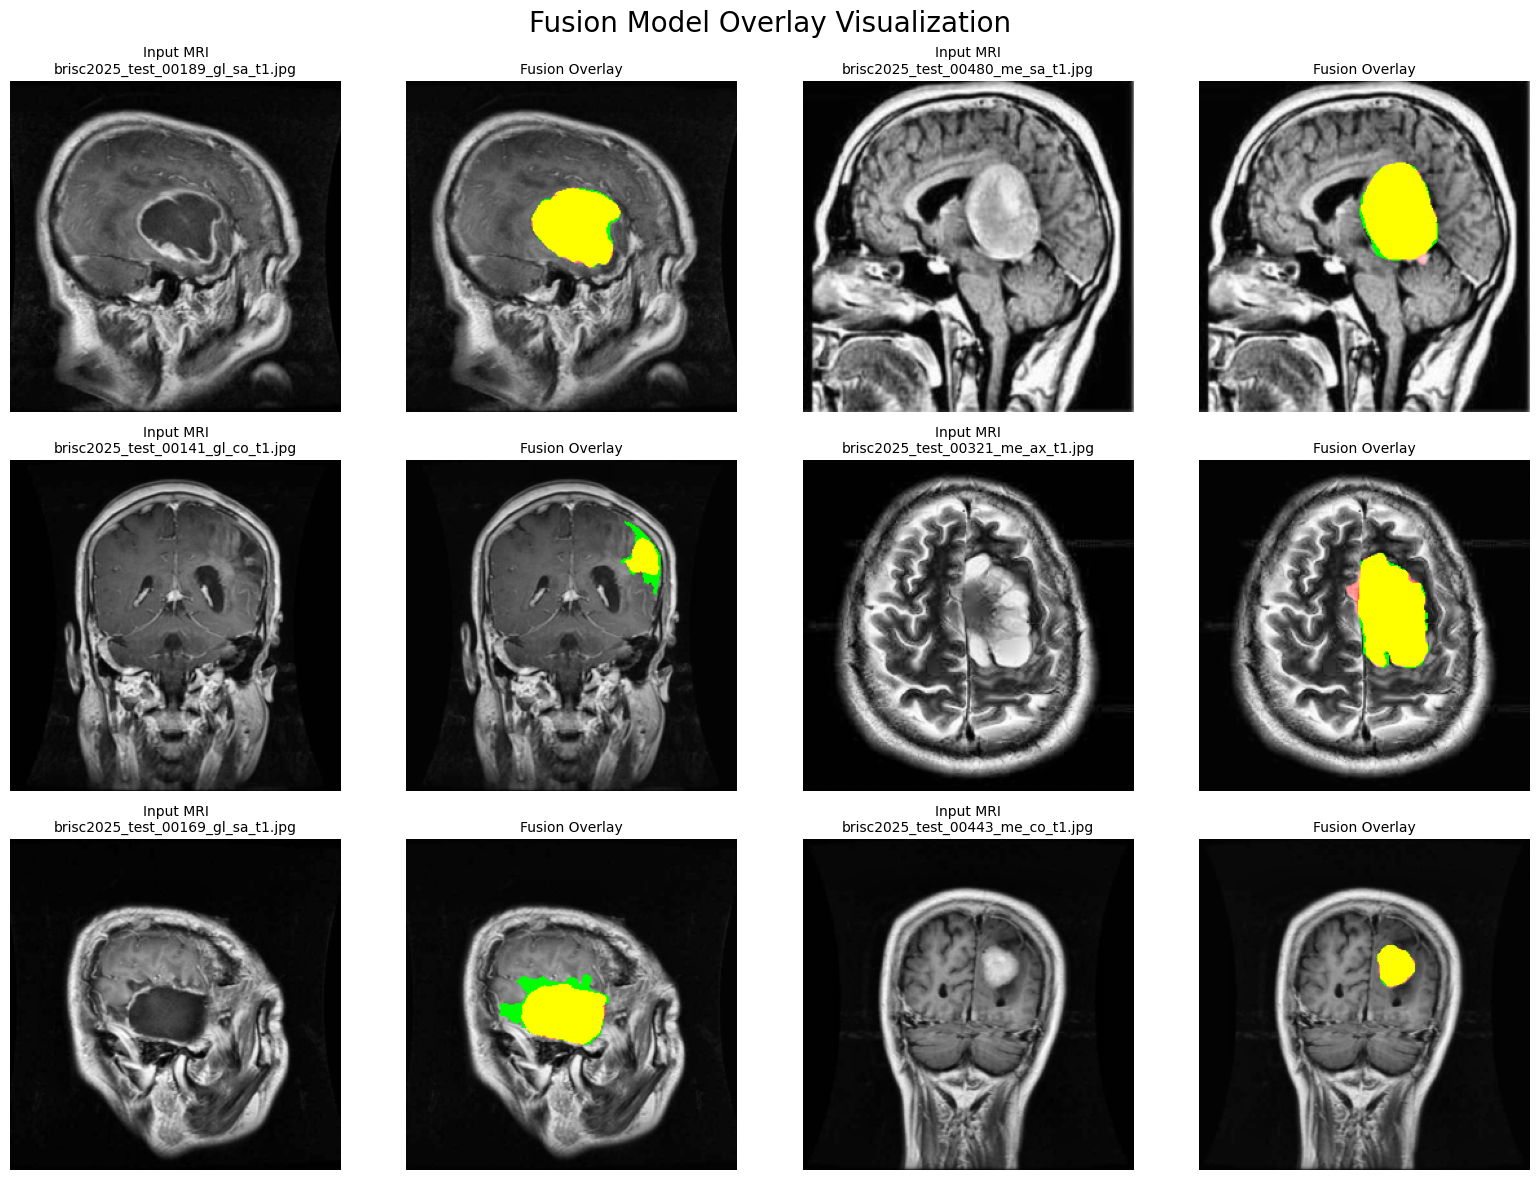

In [51]:
import math
def create_rgb_overlay(img_pil, true_mask, pred_mask, target_size=(256, 256)):
    """
    Creates an RGB overlay:
    Green channel = Ground Truth
    Red channel = Prediction
    """

    img_np = np.array(img_pil.resize(target_size)).astype(np.float32) / 255.0

    if len(img_np.shape) == 2:
        rgb = np.stack([img_np, img_np, img_np], axis=-1)
    else:
        rgb = img_np

    overlay = np.copy(rgb)

    overlay[true_mask == 1, 1] = 1.0
    overlay[true_mask == 1, 0] = 0.0
    overlay[true_mask == 1, 2] = 0.0

    overlay[pred_mask == 1, 0] = 1.0

    return overlay

num_samples = 6
viz_indices = np.random.choice(len(dataset), num_samples, replace=False)

examples_per_row = 2
cols = 4
rows = math.ceil(num_samples / examples_per_row)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(16, 4 * rows)
)

if rows == 1:
    axes = np.expand_dims(axes, axis=0)

plt.suptitle(
    "Fusion Model Overlay Visualization",
    fontsize=20
)

for idx_num, idx in enumerate(viz_indices):

    row = idx_num // examples_per_row

    col_base = (idx_num % examples_per_row) * 2

    img_att, img_swin, raw_img, mask, name = dataset[idx]

    img_att_b = img_att.unsqueeze(0).to(DEVICE)
    img_swin_b = img_swin.unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        out_ens = ensemble_model(img_att_b, img_swin_b)

        p_fus = (
            (out_ens > 0.5)
            .float()
            .cpu()
            .numpy()[0, 0]
        )

    mask_np = mask.numpy()[0]

    img_pil = transforms.ToPILImage()(raw_img)

    axes[row, col_base].imshow(
        img_pil,
        cmap='gray'
    )

    axes[row, col_base].set_title(
        f"Input MRI\n{name}",
        fontsize=10
    )

    axes[row, col_base].axis('off')

    overlay = create_rgb_overlay(
        img_pil,
        mask_np,
        p_fus
    )

    axes[row, col_base + 1].imshow(overlay)

    axes[row, col_base + 1].set_title(
        "Fusion Overlay",
        fontsize=10
    )

    axes[row, col_base + 1].axis('off')

total_plots = rows * cols
used_plots = num_samples * 2

for empty_idx in range(used_plots, total_plots):

    row = empty_idx // cols
    col = empty_idx % cols

    axes[row, col].axis('off')

plt.tight_layout()

plt.subplots_adjust(top=0.92)

plt.savefig(
    "../results/fusion_overlay_grid.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

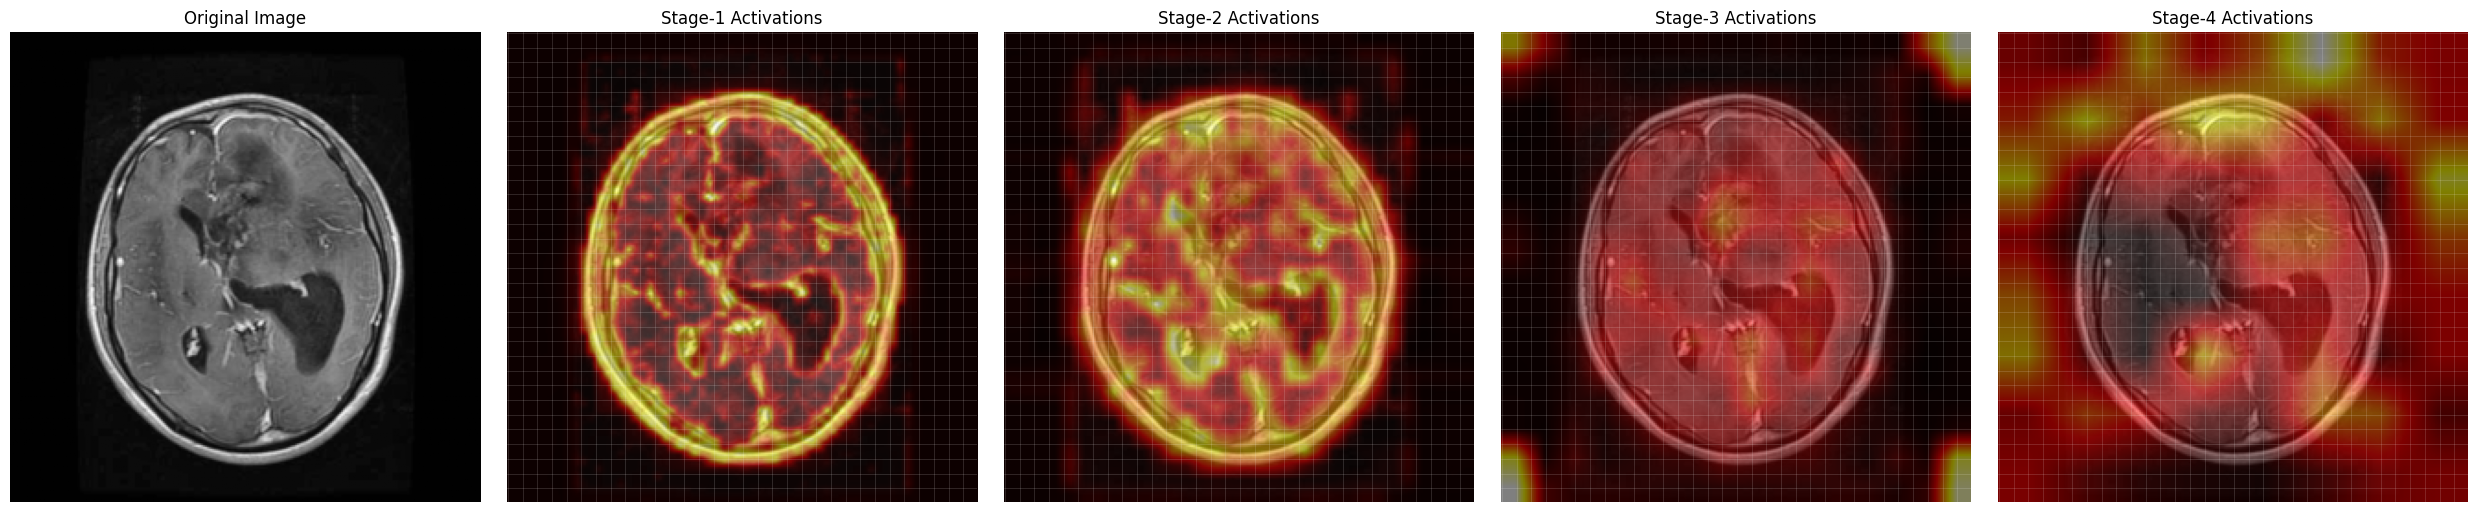

In [41]:
def get_swin_stage_activations(img_swin):
    with torch.no_grad():
        e1, e2, e3, e4 = swin_model.encoder(img_swin)

        feature_maps = [e1, e2, e3, e4]
        activations = []

        for feat in feature_maps:

            act = torch.norm(feat, dim=1).cpu().numpy()[0]

            act = (act - act.min()) / (act.max() - act.min() + 1e-6)

            act = cv2.resize(act, (256, 256))

            activations.append(act)

    return activations

for i, (img_att, img_swin, raw_img, mask, name) in enumerate(loader):

    if mask.sum() > 2000:

        sample_img_swin = img_swin.to(DEVICE)
        sample_raw = raw_img[0, 0].numpy()

        break

act1, act2, act3, act4 = get_swin_stage_activations(sample_img_swin)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(sample_raw, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

activation_maps = [act1, act2, act3, act4]
titles = [
    "Stage-1 Activations",
    "Stage-2 Activations",
    "Stage-3 Activations",
    "Stage-4 Activations"
]

for idx in range(4):

    axes[idx + 1].imshow(sample_raw, cmap='gray')

    axes[idx + 1].imshow(
        activation_maps[idx],
        cmap='hot',
        alpha=0.5
    )

    axes[idx + 1].set_title(titles[idx])

    for x in range(0, 256, 8):
        axes[idx + 1].axvline(
            x,
            color='white',
            lw=0.4,
            alpha=0.25
        )

        axes[idx + 1].axhline(
            x,
            color='white',
            lw=0.4,
            alpha=0.25
        )

    axes[idx + 1].axis('off')

plt.tight_layout()
plt.show()